In [ ]:
# [Cell 1: Fixed Installation Name]
# [Cell 1: Fixed Installation]
!pip install -q scanpy anndata scvi-tools harmonypy pydeseq2 gseapy liana decoupler omnipath GEOparse scrublet leidenalg igraph
# [Cell 2: Imports & Configuration]
import os
import urllib.request
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import harmonypy as hm
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import gseapy as gp
import liana as li
import decoupler as dc

# Reproducibility constraints
RANDOM_SEED = 42
sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=150, format='pdf', transparent=True)
np.random.seed(RANDOM_SEED)

print("Environment successfully initialized.")
print(f"Scanpy version: {sc.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 11.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 28.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 95.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 699.1/699.1 kB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 634.7/634.7 kB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 563.9/563.9 kB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# [Cell 3: MTX Download & R-Bridge Setup]
import os
import urllib.request
import pandas as pd
import scanpy as sc

# 1. Download the raw matrix components
base_url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE130nnn/GSE130973/suppl/"
files_to_download = {
    "matrix": "GSE130973_matrix_filtered.mtx.gz",
    "barcodes": "GSE130973_barcodes_filtered.tsv.gz",
    "genes": "GSE130973_genes_filtered.tsv.gz"
}

os.makedirs('data/raw', exist_ok=True)
for key, filename in files_to_download.items():
    local_path = os.path.join('data/raw', filename)
    if not os.path.exists(local_path):
        print(f"Downloading {filename}...")
        urllib.request.urlretrieve(base_url + filename, local_path)

# 2. Enable R inside Python to crack the Seurat object
%load_ext rpy2.ipython

In [ ]:
%%R
# [Cell 4: Execute R-Extraction (Runs in R)]
# We download the author's official Seurat object, read it, and extract the metadata.
# (You may see a warning about "package Seurat is not available" — this is safe to ignore,
# base R can still extract the slots).

options(timeout=600)
rds_url <- "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE130nnn/GSE130973/suppl/GSE130973_seurat_analysis_lyko.rds.gz"

if (!file.exists("data/raw/GSE130973_seurat_analysis_lyko.rds.gz")) {
    cat("Downloading Author's Seurat RDS file (441 MB). This takes ~30 seconds...\n")
    download.file(rds_url, "data/raw/GSE130973_seurat_analysis_lyko.rds.gz")
}

if (!file.exists("data/raw/GSE130973_seurat_analysis_lyko.rds")) {
    system("gunzip -f data/raw/GSE130973_seurat_analysis_lyko.rds.gz")
}

cat("Extracting ground-truth metadata from S4 object...\n")
seurat_obj <- readRDS("data/raw/GSE130973_seurat_analysis_lyko.rds")

# Extract the metadata slot directly and write to CSV for Python
meta_df <- slot(seurat_obj, "meta.data")
write.csv(meta_df, "data/raw/ground_truth_metadata.csv")
cat("Metadata successfully extracted to CSV!\n")

Extracting ground-truth metadata from S4 object...
Metadata successfully extracted to CSV!


trying URL 'https://ftp.ncbi.nlm.nih.gov/geo/series/GSE130nnn/GSE130973/suppl/GSE130973_seurat_analysis_lyko.rds.gz'
Content type 'application/x-gzip' length 462376986 bytes (441.0 MB)
downloaded 441.0 MB



In [ ]:
# [Cell 5: Matrix Ingestion & Metadata Alignment (Runs in Python)]
print("Ingesting Matrix Market (MTX) layout...")
adata = sc.read_mtx('data/raw/GSE130973_matrix_filtered.mtx.gz').T

# Load MTX barcodes and genes
barcodes = pd.read_csv('data/raw/GSE130973_barcodes_filtered.tsv.gz', header=None, sep='\t')[0].values
genes_df = pd.read_csv('data/raw/GSE130973_genes_filtered.tsv.gz', header=None, sep='\t')

adata.obs_names = barcodes
adata.var_names = genes_df[1].values if genes_df.shape[1] >= 2 else genes_df[0].values
adata.var_names_make_unique()

# Load Ground Truth Metadata
print("Aligning ground-truth metadata...")
meta_df = pd.read_csv('data/raw/ground_truth_metadata.csv', index_col=0)

# Authors sometimes tweak barcode names (e.g. replacing '-' with '_').
# We intersect them to guarantee a perfect match.
common_barcodes = adata.obs_names.intersection(meta_df.index)

if len(common_barcodes) == 0:
    print("WARNING: Exact string match failed. Attempting to strip suffixes to force alignment...")
    # Strip numeric suffixes (e.g., "-1") from both sides to align by raw ATCG sequence
    adata.obs['raw_barcode'] = adata.obs_names.str.split('-').str[0].str.split('_').str[0]
    meta_df['raw_barcode'] = meta_df.index.str.split('-').str[0].str.split('_').str[0]

    # Map metadata onto AnnData
    meta_df_dedup = meta_df.drop_duplicates(subset=['raw_barcode']).set_index('raw_barcode')
    for col in meta_df.columns:
        if col != 'raw_barcode':
            adata.obs[col] = adata.obs['raw_barcode'].map(meta_df_dedup[col])
else:
    # Perfect string match exists
    adata = adata[common_barcodes].copy()
    adata.obs = adata.obs.join(meta_df)

# Ensure our crucial pipeline variables are standardized
if 'Age' in adata.obs.columns:
    adata.obs['age'] = adata.obs['Age'] # Standardize capitalization
if 'Condition' in adata.obs.columns and 'age' not in adata.obs.columns:
    adata.obs['age'] = adata.obs['Condition']
if 'orig.ident' in adata.obs.columns:
    adata.obs['donor'] = adata.obs['orig.ident'] # Seurat's default project/donor ID
adata.obs['batch'] = adata.obs['donor']

print("\n--- INGESTION REPORT (VERIFIED) ---")
print(f"Dimensions: {adata.n_obs} cells x {adata.n_vars} features successfully reconstructed.")
print("\nDonor Stratification:\n", adata.obs['donor'].value_counts(dropna=False))
print("\nAge Cohort Stratification:\n", adata.obs['age'].value_counts(dropna=False))

Ingesting Matrix Market (MTX) layout...
Aligning ground-truth metadata...

--- INGESTION REPORT (VERIFIED) ---
Dimensions: 15457 cells x 32738 features successfully reconstructed.

Donor Stratification:
 donor
10X_PBMC    15457
Name: count, dtype: int64

Age Cohort Stratification:
 age
OLD      10003
YOUNG     5454
Name: count, dtype: int64


In [ ]:
# [Diagnostic Cell: Hunt for the real Donor ID]
import pandas as pd
meta_df = pd.read_csv('data/raw/ground_truth_metadata.csv', index_col=0)

print("Available Metadata Columns:")
print(meta_df.columns.tolist())

print("\nFirst 5 rows of metadata:")
display(meta_df.head(5))

Available Metadata Columns:
['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'subj', 'percent.mito', 'age', 'integrated_snn_res.0.4', 'celltype.age']

First 5 rows of metadata:


,orig.ident,nCount_RNA,nFeature_RNA,subj,percent.mito,age,integrated_snn_res.0.4,celltype.age
AAACCTGAGTTAAGTG-1,10X_PBMC,1971,852,S1,0.027905,YOUNG,6,6_YOUNG
AAACCTGTCCATTCTA-1,10X_PBMC,3148,978,S1,0.010165,YOUNG,6,6_YOUNG
AACACGTGTTCCACAA-1,10X_PBMC,4767,1466,S1,0.018670,YOUNG,6,6_YOUNG
AACCGCGCACGCGAAA-1,10X_PBMC,2487,879,S1,0.028951,YOUNG,6,6_YOUNG
AACCGCGCACTGAAGG-1,10X_PBMC,1983,838,S1,0.033787,YOUNG,6,6_YOUNG


In [ ]:
# [Cell 5b: Patch True Donor IDs]
# We map the 'subj' column to our critical 'donor' and 'batch' variables
adata.obs['donor'] = adata.obs['subj']
adata.obs['batch'] = adata.obs['subj']

print("--- FIXED DONOR STRATIFICATION ---")
print(adata.obs['donor'].value_counts())
print(f"Total biologically distinct donors: {adata.obs['donor'].nunique()}")

--- FIXED DONOR STRATIFICATION ---
donor
S5    4535
S3    3324
S1    2784
S2    2670
S4    2144
Name: count, dtype: int64
Total biologically distinct donors: 5


In [ ]:
# [Cell 6: Section C - Quality Control]
import scrublet as scr
import numpy as np

print(f"Cells before QC: {adata.n_obs}")

# 1. Flag Mitochondrial and Ribosomal genes
adata.var['mt'] = adata.var_names.str.startswith('MT-')
adata.var['ribo'] = adata.var_names.str.startswith(('RPS', 'RPL'))
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'ribo'], percent_top=None, log1p=False, inplace=True)

# 2. Scrublet Doublet Detection (Must be run per donor)
print("Running Scrublet doublet detection per donor...")
adata.obs['doublet_score'] = 0.0
adata.obs['predicted_doublet'] = False

for batch in adata.obs['donor'].unique():
    subset = adata[adata.obs['donor'] == batch].copy()
    if subset.n_obs > 50: # Safety check
        scrub = scr.Scrublet(subset.X)
        doublet_scores, predicted_doublets = scrub.scrub_doublets()
        adata.obs.loc[subset.obs_names, 'doublet_score'] = doublet_scores
        adata.obs.loc[subset.obs_names, 'predicted_doublet'] = predicted_doublets

doublet_count = adata.obs['predicted_doublet'].sum()
print(f"Detected {doublet_count} doublets.")

# 3. Apply Strict Filtering Thresholds
# We require >500 genes to protect downstream Gene Regulatory Network inference
sc.pp.filter_cells(adata, min_genes=500)
sc.pp.filter_genes(adata, min_cells=10)
adata = adata[adata.obs['pct_counts_mt'] < 10, :] # Remove dying cells (>10% MT)
adata = adata[~adata.obs['predicted_doublet'], :] # Remove doublets

print(f"Cells after QC: {adata.n_obs}")

# 4. Save the raw counts layer!
# PyDESeq2 strictly requires un-normalized integers. We must save them before the next step.
adata.layers["counts"] = adata.X.copy()
adata.raw = adata
print("Raw counts saved to adata.layers['counts']. QC Complete.")

Cells before QC: 15457
Running Scrublet doublet detection per donor...
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.64
Detected doublet rate = 0.5%
Estimated detectable doublet fraction = 10.0%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 5.0%
Elapsed time: 3.8 seconds
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.47
Detected doublet rate = 0.8%
Estimated detectable doublet fraction = 23.2%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 3.4%
Elapsed time: 2.8 seconds
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.40
Detected doublet rate = 1.4%
Estimated detectable doublet fraction = 41.8%
Overall doublet rate:
	Expected   = 10.0%
	Estimat

/tmp/ipykernel_2304/1865348051.py:39: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.


Raw counts saved to adata.layers['counts']. QC Complete.


Checking memory state...
Normalizing raw counts...
normalizing counts per cell
    finished (0:00:02)
Identifying Highly Variable Genes (HVGs)...
extracting highly variable genes
    finished (0:00:02)
Subsetting memory to HVGs...
Scaling data and computing PCA...
... be careful when using `max_value` without `zero_center`.
computing PCA
    with n_comps=50
    finished (0:00:01)


2026-06-04 14:52:51,015 - harmonypy - INFO - Running Harmony
INFO:harmonypy:Running Harmony
2026-06-04 14:52:51,018 - harmonypy - INFO -   Parameters:
INFO:harmonypy:  Parameters:
2026-06-04 14:52:51,021 - harmonypy - INFO -     max_iter_harmony: 10
INFO:harmonypy:    max_iter_harmony: 10
2026-06-04 14:52:51,024 - harmonypy - INFO -     max_iter_kmeans: 4
INFO:harmonypy:    max_iter_kmeans: 4
2026-06-04 14:52:51,027 - harmonypy - INFO -     epsilon_cluster: 0.001
INFO:harmonypy:    epsilon_cluster: 0.001
2026-06-04 14:52:51,029 - harmonypy - INFO -     epsilon_harmony: 0.01
INFO:harmonypy:    epsilon_harmony: 0.01
2026-06-04 14:52:51,032 - harmonypy - INFO -     nclust: 100
INFO:harmonypy:    nclust: 100
2026-06-04 14:52:51,034 - harmonypy - INFO -     block_size: 0.05
INFO:harmonypy:    block_size: 0.05
2026-06-04 14:52:51,037 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
INFO:harmonypy:    lamb: dynamic (alpha=0.2)
2026-06-04 14:52:51,040 - harmonypy - INFO -     theta: [2. 2. 2

Running Harmony Integration across donors...


2026-06-04 14:52:51,844 - harmonypy - INFO - Initialization complete.
INFO:harmonypy:Initialization complete.
2026-06-04 14:52:51,847 - harmonypy - INFO - Iteration 1 of 10
INFO:harmonypy:Iteration 1 of 10
2026-06-04 14:52:52,434 - harmonypy - INFO - Iteration 2 of 10
INFO:harmonypy:Iteration 2 of 10
2026-06-04 14:52:53,070 - harmonypy - INFO - Iteration 3 of 10
INFO:harmonypy:Iteration 3 of 10
2026-06-04 14:52:53,707 - harmonypy - INFO - Iteration 4 of 10
INFO:harmonypy:Iteration 4 of 10
2026-06-04 14:52:54,278 - harmonypy - INFO - Iteration 5 of 10
INFO:harmonypy:Iteration 5 of 10
2026-06-04 14:52:54,680 - harmonypy - INFO - Converged after 5 iterations
INFO:harmonypy:Converged after 5 iterations


Intercepting Harmony output and enforcing modern array shapes...
Successfully aligned Corrected PCA matrix: (14698, 50)
Computing neighbor graph and UMAP...
computing neighbors
    finished (0:01:09)
computing UMAP
    finished (0:00:12)
Running Leiden clustering...
running Leiden clustering
    finished (0:00:06)
Generating plots...


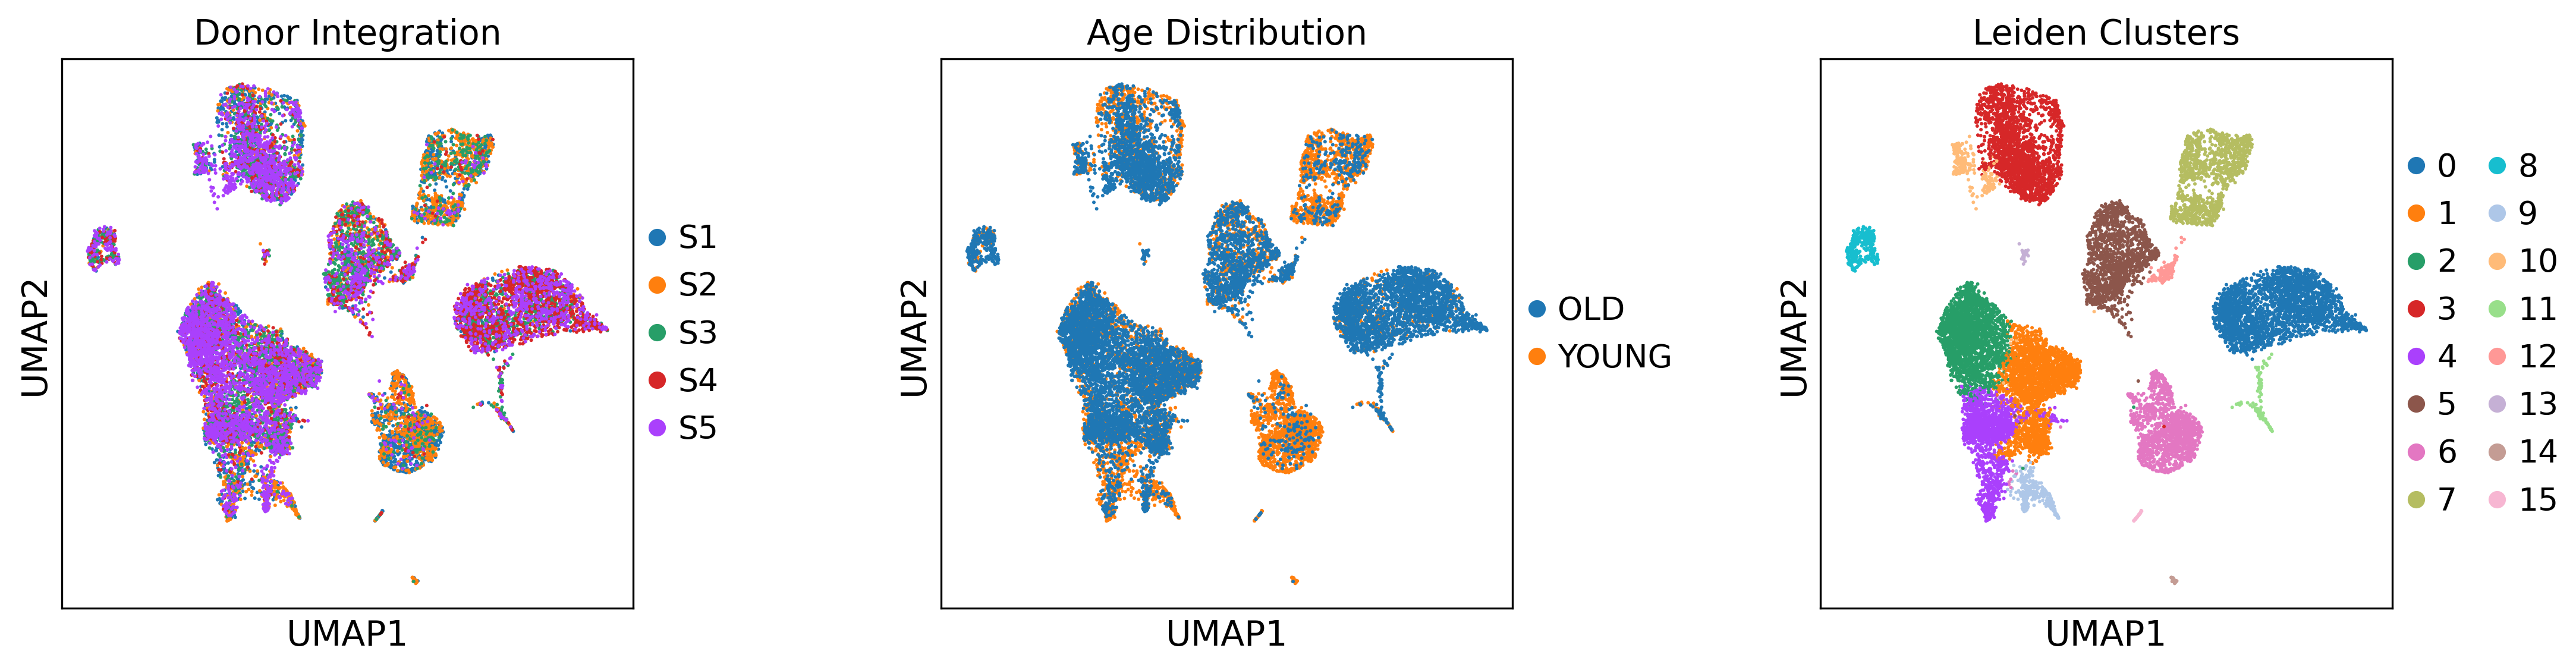

In [ ]:
# [Cell 7: Section D - Batch Correction & Harmony (SHAPE ENFORCER)]
import harmonypy as hm
import numpy as np

print("Checking memory state...")
# SAFETY LOCK: Prevent running on already-scaled data
if 'X_pca' in adata.obsm:
    raise RuntimeError("MEMORY CORRUPTION DETECTED: You must re-run Cell 5 and Cell 6 to reset the raw counts before running this cell.")

print("Normalizing raw counts...")
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

print("Identifying Highly Variable Genes (HVGs)...")
sc.pp.highly_variable_genes(adata, n_top_genes=3000)

print("Subsetting memory to HVGs...")
adata = adata[:, adata.var.highly_variable].copy()

print("Scaling data and computing PCA...")
# zero_center=False keeps the matrix sparse and prevents RAM blowouts
sc.pp.scale(adata, max_value=10, zero_center=False)
sc.tl.pca(adata, svd_solver='arpack')

print("Running Harmony Integration across donors...")
pca_matrix = adata.obsm['X_pca']
harmony_out = hm.run_harmony(pca_matrix, adata.obs, 'donor')

print("Intercepting Harmony output and enforcing modern array shapes...")
# Force conversion from deprecated numpy.matrix to modern numpy.ndarray
z_corr_array = np.array(harmony_out.Z_corr)

# Mathematically guarantee the shape aligns with (Cells x PCs)
if z_corr_array.shape[0] == adata.n_obs:
    corrected_pca = z_corr_array
elif z_corr_array.shape[1] == adata.n_obs:
    corrected_pca = z_corr_array.T
else:
    raise ValueError(f"CRITICAL SHAPE ERROR: Harmony returned {z_corr_array.shape}, which matches neither Cells ({adata.n_obs}) nor PCs.")

print(f"Successfully aligned Corrected PCA matrix: {corrected_pca.shape}")
adata.obsm['X_pca_harmony'] = corrected_pca

print("Computing neighbor graph and UMAP...")
sc.pp.neighbors(adata, n_pcs=30, use_rep='X_pca_harmony')
sc.tl.umap(adata)

print("Running Leiden clustering...")
sc.tl.leiden(adata, resolution=0.4)

print("Generating plots...")
sc.pl.umap(adata, color=['donor', 'age', 'leiden'], wspace=0.4,
           title=['Donor Integration', 'Age Distribution', 'Leiden Clusters'])

Scoring cells against canonical signatures...
computing score 'Fibroblasts_score'
    finished (0:00:00)
computing score 'Macrophages_score'
    finished (0:00:00)
computing score 'Endothelial_score'
    finished (0:00:00)
computing score 'Keratinocytes_score'
    finished (0:00:00)
computing score 'T_Cells_score'
    finished (0:00:00)
computing score 'Melanocytes_score'
    finished (0:00:00)
Mapping signatures to Leiden clusters...

--- ANNOTATION REPORT ---
cell_type
Fibroblasts      5860
Macrophages      3631
Keratinocytes    2490
Unknown          1376
T_Cells          1212
Melanocytes       129
Name: count, dtype: int64

Generating annotation plots...


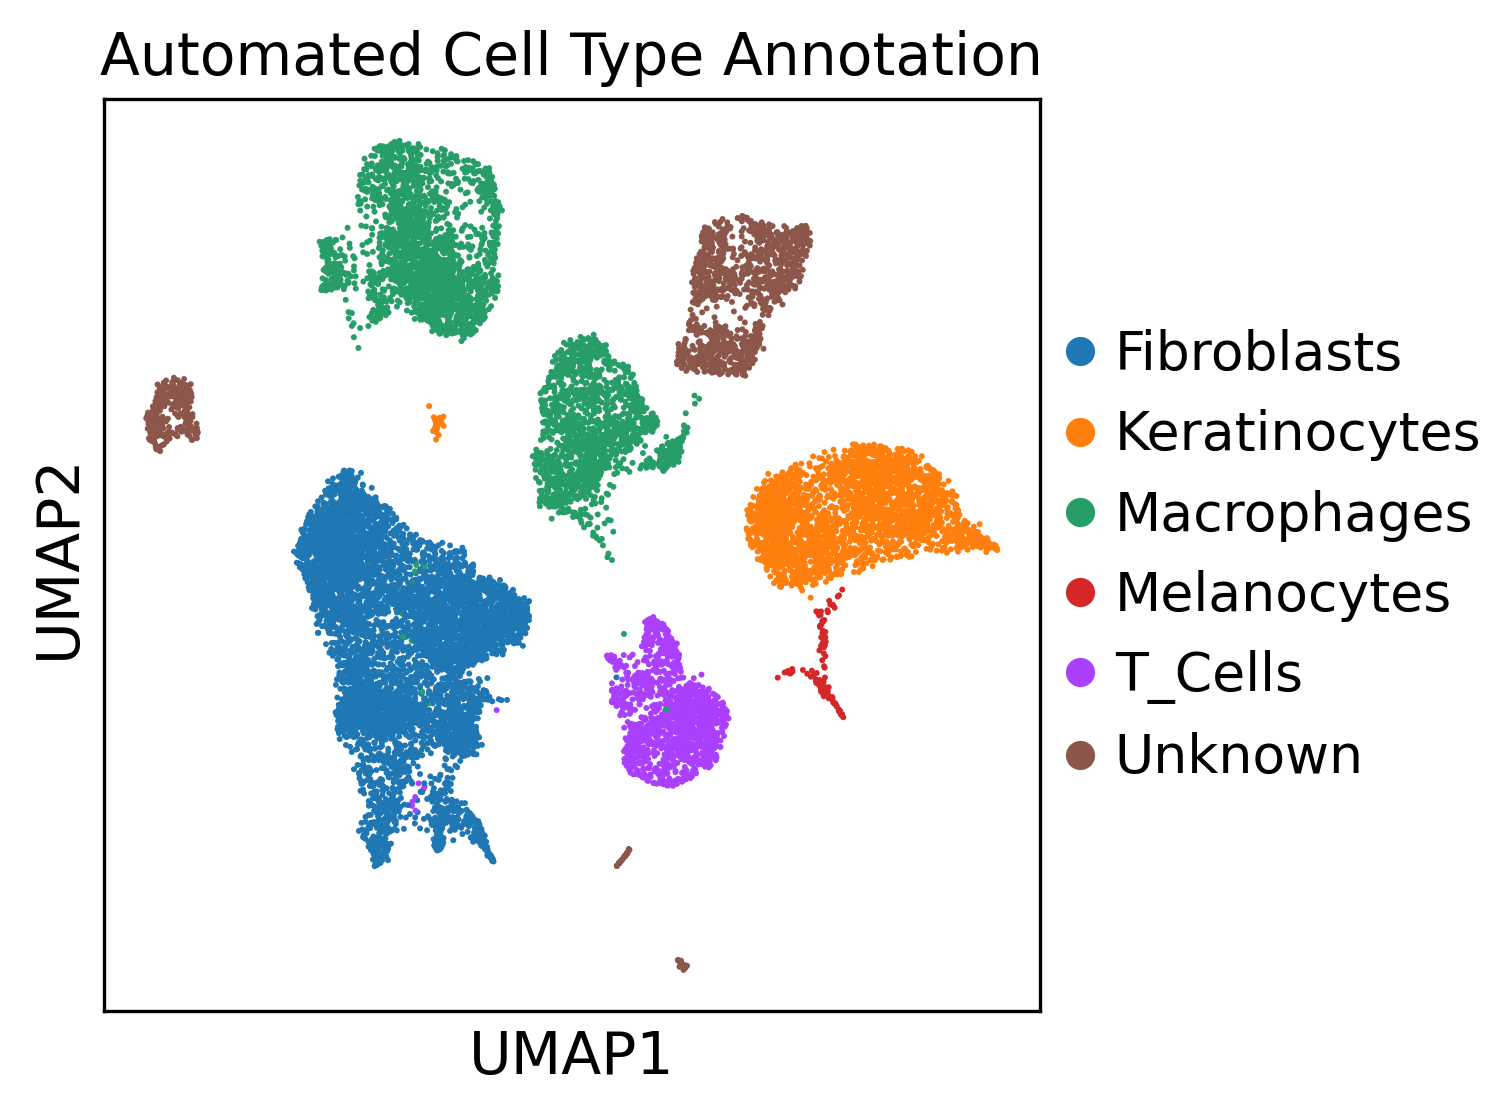

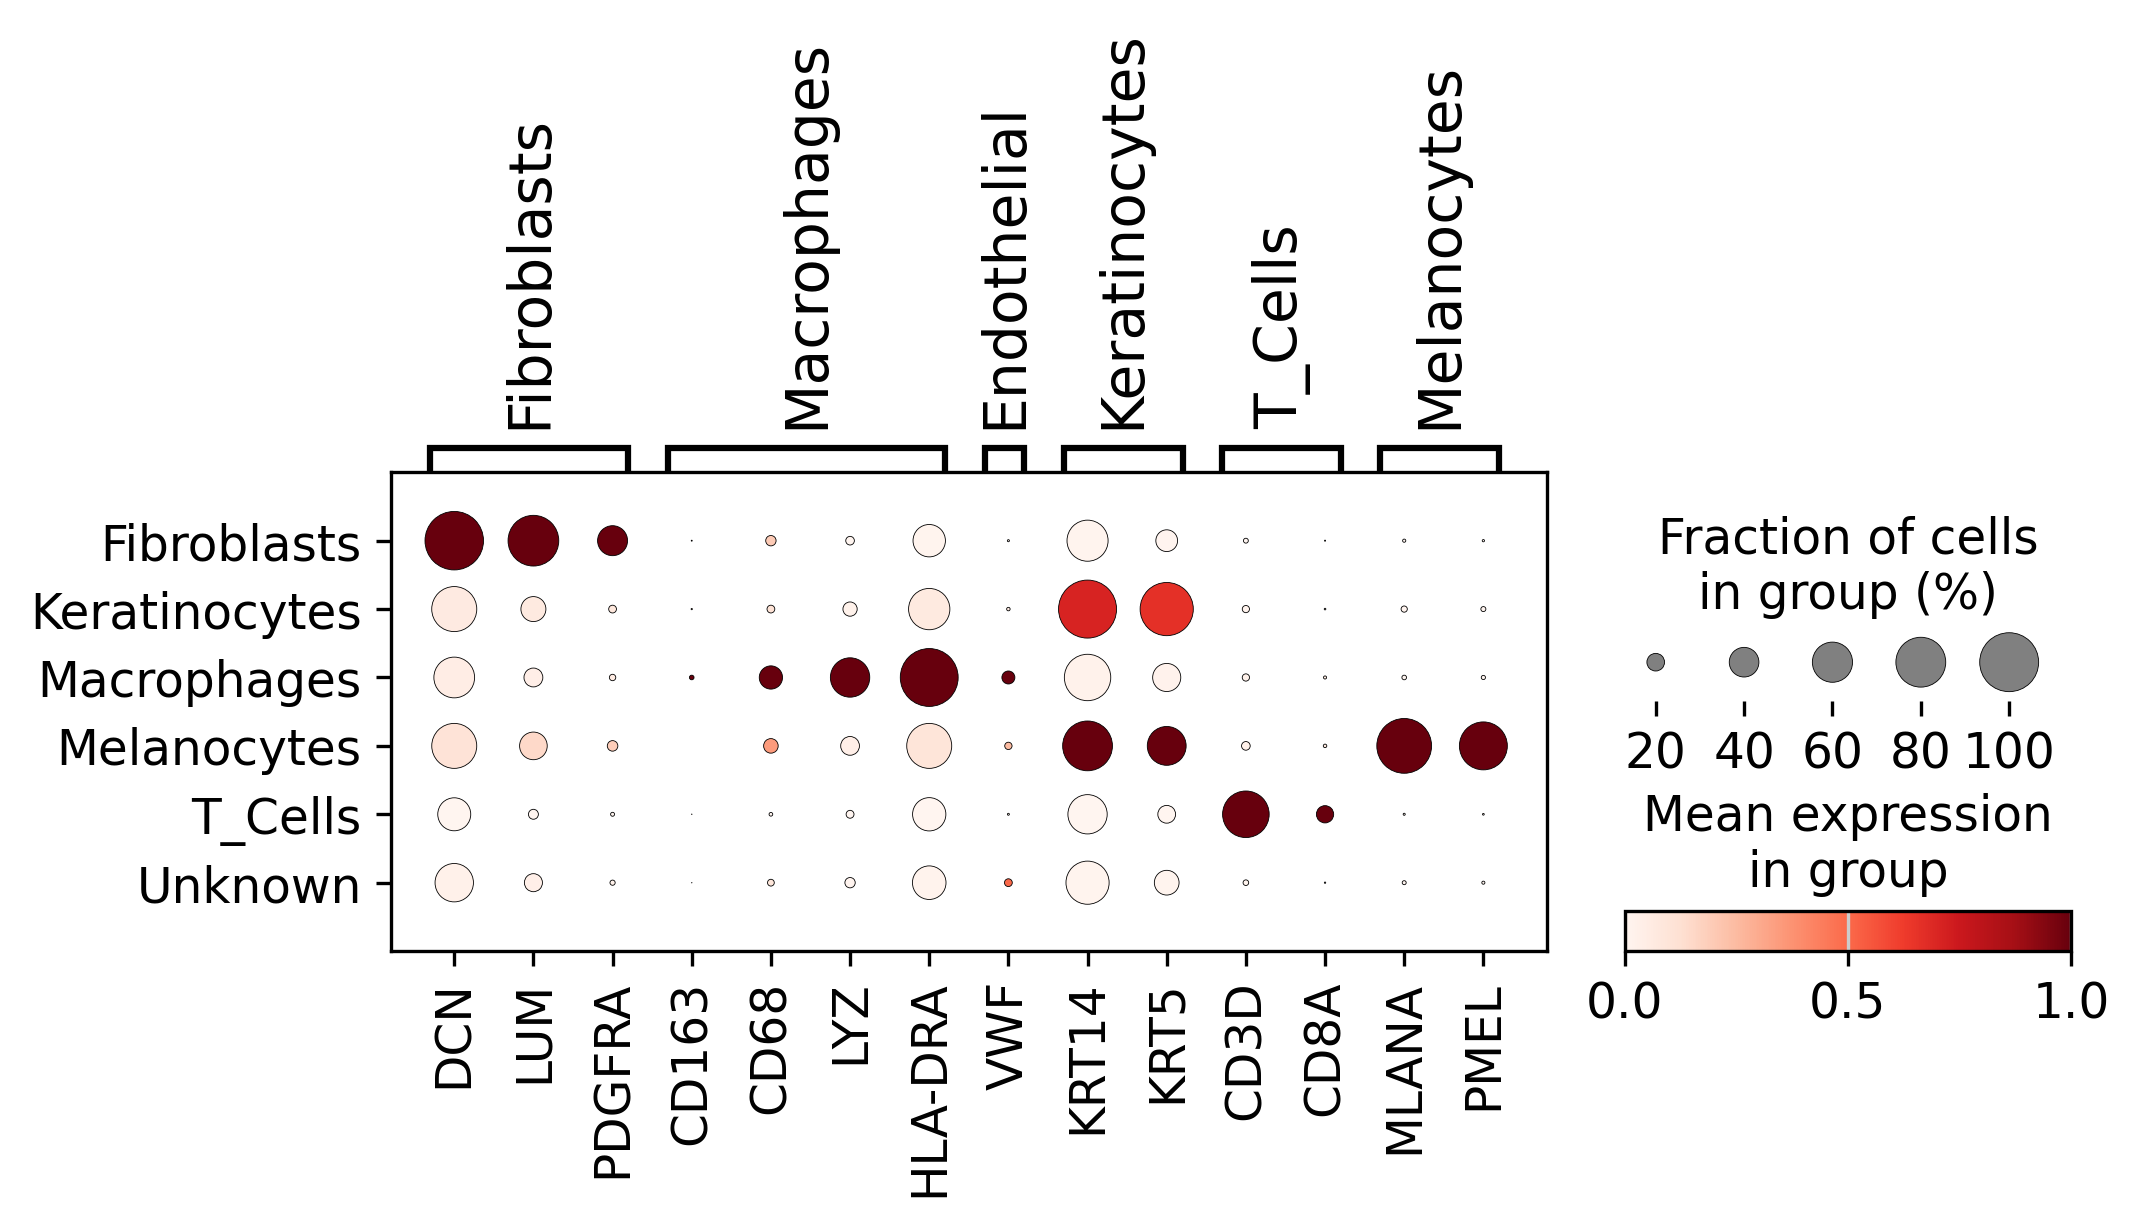

In [ ]:
# [Cell 8: Section E - Automated Cell Type Annotation]
import pandas as pd
import scanpy as sc

# 1. Define Canonical Markers for Skin Resident Cells
canonical_markers = {
    'Fibroblasts': ['DCN', 'LUM', 'PDGFRA'],
    'Macrophages': ['CD163', 'CD68', 'LYZ', 'HLA-DRA'],
    'Endothelial': ['PECAM1', 'VWF', 'CDH5'],
    'Keratinocytes': ['KRT14', 'KRT5'],
    'T_Cells': ['CD3D', 'CD8A'],
    'Melanocytes': ['MLANA', 'PMEL']
}

print("Scoring cells against canonical signatures...")
# 2. Score each cell for each signature
score_names = []
for cell_type, markers in canonical_markers.items():
    # Filter markers to only those present in our highly variable genes
    valid_markers = [m for m in markers if m in adata.var_names]
    if valid_markers:
        score_name = f'{cell_type}_score'
        sc.tl.score_genes(adata, gene_list=valid_markers, score_name=score_name)
        score_names.append(score_name)
    else:
        print(f"Warning: No markers found for {cell_type} in HVGs.")

# 3. Assign cell types to clusters based on highest median score
print("Mapping signatures to Leiden clusters...")
cluster_median_scores = adata.obs.groupby('leiden', observed=False)[score_names].median()

# Find the signature with the max score for each cluster
cluster_mapping = {}
for cluster in cluster_median_scores.index:
    best_score_col = cluster_median_scores.loc[cluster].idxmax()
    best_score_val = cluster_median_scores.loc[cluster, best_score_col]

    # Simple threshold to catch "Unknown" clusters (junk/noise or rare cells)
    if best_score_val > 0.05:
        assigned_type = best_score_col.replace('_score', '')
    else:
        assigned_type = 'Unknown'

    cluster_mapping[cluster] = assigned_type

# 4. Apply the mapping to the AnnData object
adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_mapping)

print("\n--- ANNOTATION REPORT ---")
print(adata.obs['cell_type'].value_counts())

# 5. Visualize the final annotated manifold and marker dotplot
print("\nGenerating annotation plots...")
sc.pl.umap(adata, color='cell_type', title='Automated Cell Type Annotation')

# Generate the dotplot to visually verify the algorithm's choices
valid_marker_dict = {k: [m for m in v if m in adata.var_names] for k, v in canonical_markers.items()}
sc.pl.dotplot(adata, valid_marker_dict, groupby='cell_type', standard_scale='var')

In [ ]:
# [Cell 9: Section F & G - Subsetting & Pseudobulk DE (Fibroblasts)]
import pandas as pd
import numpy as np
import scipy.sparse as sp
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

print("1. Isolating Fibroblasts...")
# Subset to only fibroblasts to save memory and focus the analysis
fibro_adata = adata[adata.obs['cell_type'] == 'Fibroblasts'].copy()
print(f"Isolated {fibro_adata.n_obs} Fibroblasts.")

print("\n2. Aggregating single cells into Pseudobulk samples...")
def create_pseudobulk(adata_subset, condition_col='age', sample_col='donor', layer='counts'):
    # Extract the raw, un-normalized counts saved in Cell 6
    raw_mat = adata_subset.layers[layer]
    if sp.issparse(raw_mat):
        raw_mat = raw_mat.toarray()

    df = pd.DataFrame(raw_mat, index=adata_subset.obs.index, columns=adata_subset.var_names)
    df['sample_id'] = adata_subset.obs[sample_col].astype(str)
    df['condition'] = adata_subset.obs[condition_col].astype(str)

    # Sum counts per donor
    pb_df = df.groupby(['sample_id', 'condition']).sum().reset_index()

    # Build metadata and count matrix
    metadata = pb_df[['sample_id', 'condition']].set_index('sample_id')
    counts = pb_df.drop('condition', axis=1).set_index('sample_id')

    # Force strict integers for DESeq2
    counts = counts.round().astype(int)
    return counts, metadata

pb_counts, pb_meta = create_pseudobulk(fibro_adata)

print("\nPseudobulk Cohort Metadata:")
display(pb_meta)

print("\n3. Running PyDESeq2 Statistical Modeling (Old vs Young)...")
# Initialize DESeq2 object
dds = DeseqDataSet(
    counts=pb_counts,
    metadata=pb_meta,
    design_factors="condition",
    ref_level=["condition", "YOUNG"]  # Explicitly set Young as the baseline
)

# Run the dispersion and log-fold change modeling
dds.deseq2()

# Extract the contrast (Old vs Young)
stat_res = DeseqStats(dds, contrast=["condition", "OLD", "YOUNG"])
stat_res.summary()

# Clean up the results dataframe
res_df = stat_res.results_df.dropna(subset=['padj'])

# Filter for statistically significant Differentially Expressed Genes (DEGs)
# padj < 0.05 and absolute Log2 Fold Change > 0.58 (approx 1.5x fold change)
sig_degs = res_df[(res_df['padj'] < 0.05) & (abs(res_df['log2FoldChange']) > 0.58)].copy()
sig_degs = sig_degs.sort_values('log2FoldChange', ascending=False)

print(f"\n--- DISCOVERY REPORT ---")
print(f"Found {len(sig_degs)} significant DEGs in aged Fibroblasts.")

# Save the full results to disk for the paper's supplementary tables
res_df.to_csv("Fibroblasts_Old_vs_Young_DESeq2.csv")
sig_degs.to_csv("Fibroblasts_Old_vs_Young_Significant_Only.csv")

print("\nTop 10 Upregulated Genes in Old Fibroblasts:")
display(sig_degs.head(10)[['log2FoldChange', 'padj']])

print("\nTop 10 Downregulated Genes in Old Fibroblasts:")
display(sig_degs.tail(10)[['log2FoldChange', 'padj']])

1. Isolating Fibroblasts...
Isolated 5860 Fibroblasts.

2. Aggregating single cells into Pseudobulk samples...

Pseudobulk Cohort Metadata:


,condition
sample_id,
S1,YOUNG
S2,YOUNG
S3,OLD
S4,OLD
S5,OLD



3. Running PyDESeq2 Statistical Modeling (Old vs Young)...
Using None as control genes, passed at DeseqDataSet initialization


/tmp/ipykernel_2304/743203076.py:42: DeprecationWarning: ref_level is deprecated and no longer has any effect. It will beremoved in a future release.
/tmp/ipykernel_2304/743203076.py:42: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 3.64 seconds.

Fitting dispersion trend curve...
... done in 0.22 seconds.

/usr/local/lib/python3.12/dist-packages/pydeseq2/dds.py:548: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
Fitting MAP dispersions...
... done in 3.11 seconds.

Fitting LFCs...
... done in 2.24 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: condition OLD vs YOUNG
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  \
HES4           194.022856       -0.358782  0.466887 -0.768456  0.442216   
ISG15          265.203282       -0.244201  0.506836 -0.481814  0.629938   
RP11-465B22.8    0.766584        0.370611  3.245493  0.114192  0.909085   
TNFRSF18        60.066112        1.672237  0.697952  2.395922  0.016579   
TNFRSF4         25.545247       -0.565085  0.727767 -0.776465  0.437474   
...                   ...             ...       ...       ...       ...   
CBS             16.809955       -0.811384  0.877139 -0.925034  0.354948   
ITGB2           14.920654       -0.002346  0.873154 -0.002687  0.997856   
ITGB2-AS1        3.358668       -0.068949  1.499737 -0.045974  0.963331   
COL18A1        338.216523       -0.484488  0.498822 -0.971264  0.331417   
S100B           11.079544        0.215313  0.998011  0.215742  0.829189   

                   padj  
HES4        

... done in 0.68 seconds.



,log2FoldChange,padj
IGJ,5.039555,0.000002
MPZL2,3.811835,0.001240
IGLL5,3.679648,0.002141
DEFB1,3.582157,0.004171
MAL2,3.501034,0.007593
DMKN,3.224846,0.000669
RNF144B,3.102156,0.002499
TFF3,3.095072,0.009445
S100A14,3.071064,0.007593
FGFBP1,2.962860,0.011625



Top 10 Downregulated Genes in Old Fibroblasts:


,log2FoldChange,padj
TNN,-3.392501,1.574711e-04
ZC2HC1C,-3.432063,3.178671e-02
TAC1,-3.446454,5.213000e-03
TNMD,-3.510134,1.574711e-04
C2orf40,-3.697844,3.598259e-02
MYOC,-3.705419,6.690302e-04
DCX,-3.838963,6.065230e-03
SOX2,-4.330365,1.335164e-02
COCH,-4.404230,5.845809e-09
CXCL9,-4.984793,1.063586e-02


1. Bypassing package API and fetching CollecTRI directly from Omnipath servers...
2. Parsing regulatory network...
Successfully loaded 62411 CollecTRI interactions.
3. Executing Native Parametric Enrichment Analysis (TF Inference)...
4. Processing Inference Results...

--- TRANSCRIPTION FACTOR REPORT ---
Identified 22 significantly deregulated Transcription Factors.

Top 10 ACTIVATED TFs in Old Fibroblasts (Drivers of Inflammaging?):


,TF,Activity_Score,p_value
194,RFXAP,4.926418,0.000599
192,RFX5,4.084835,0.001513
193,RFXANK,4.006496,0.002063
35,ELF1,3.756747,0.003173
179,PPARD,3.222328,0.003309
181,PRDM1,3.030664,0.009652
180,PPARG,2.921625,0.004472
16,CIITA,2.896150,0.015938
7,ATF4,2.689958,0.012546
173,PGR,2.656067,0.011491



Top 10 REPRESSED TFs in Old Fibroblasts (Loss of Structural Regulators?):


,TF,Activity_Score,p_value
140,NFIC,-2.261958,0.037976
141,NFIL3,-2.382621,0.033145
222,STAT5A,-2.483580,0.016889
230,TCF3,-2.505836,0.020970
119,MITF,-2.556013,0.016531
216,SRF,-2.596835,0.014435
90,HR,-2.645951,0.019180
127,MYOG,-2.746657,0.022600
118,MEF2C,-2.800041,0.014179
4,ATF1,-3.664469,0.002301


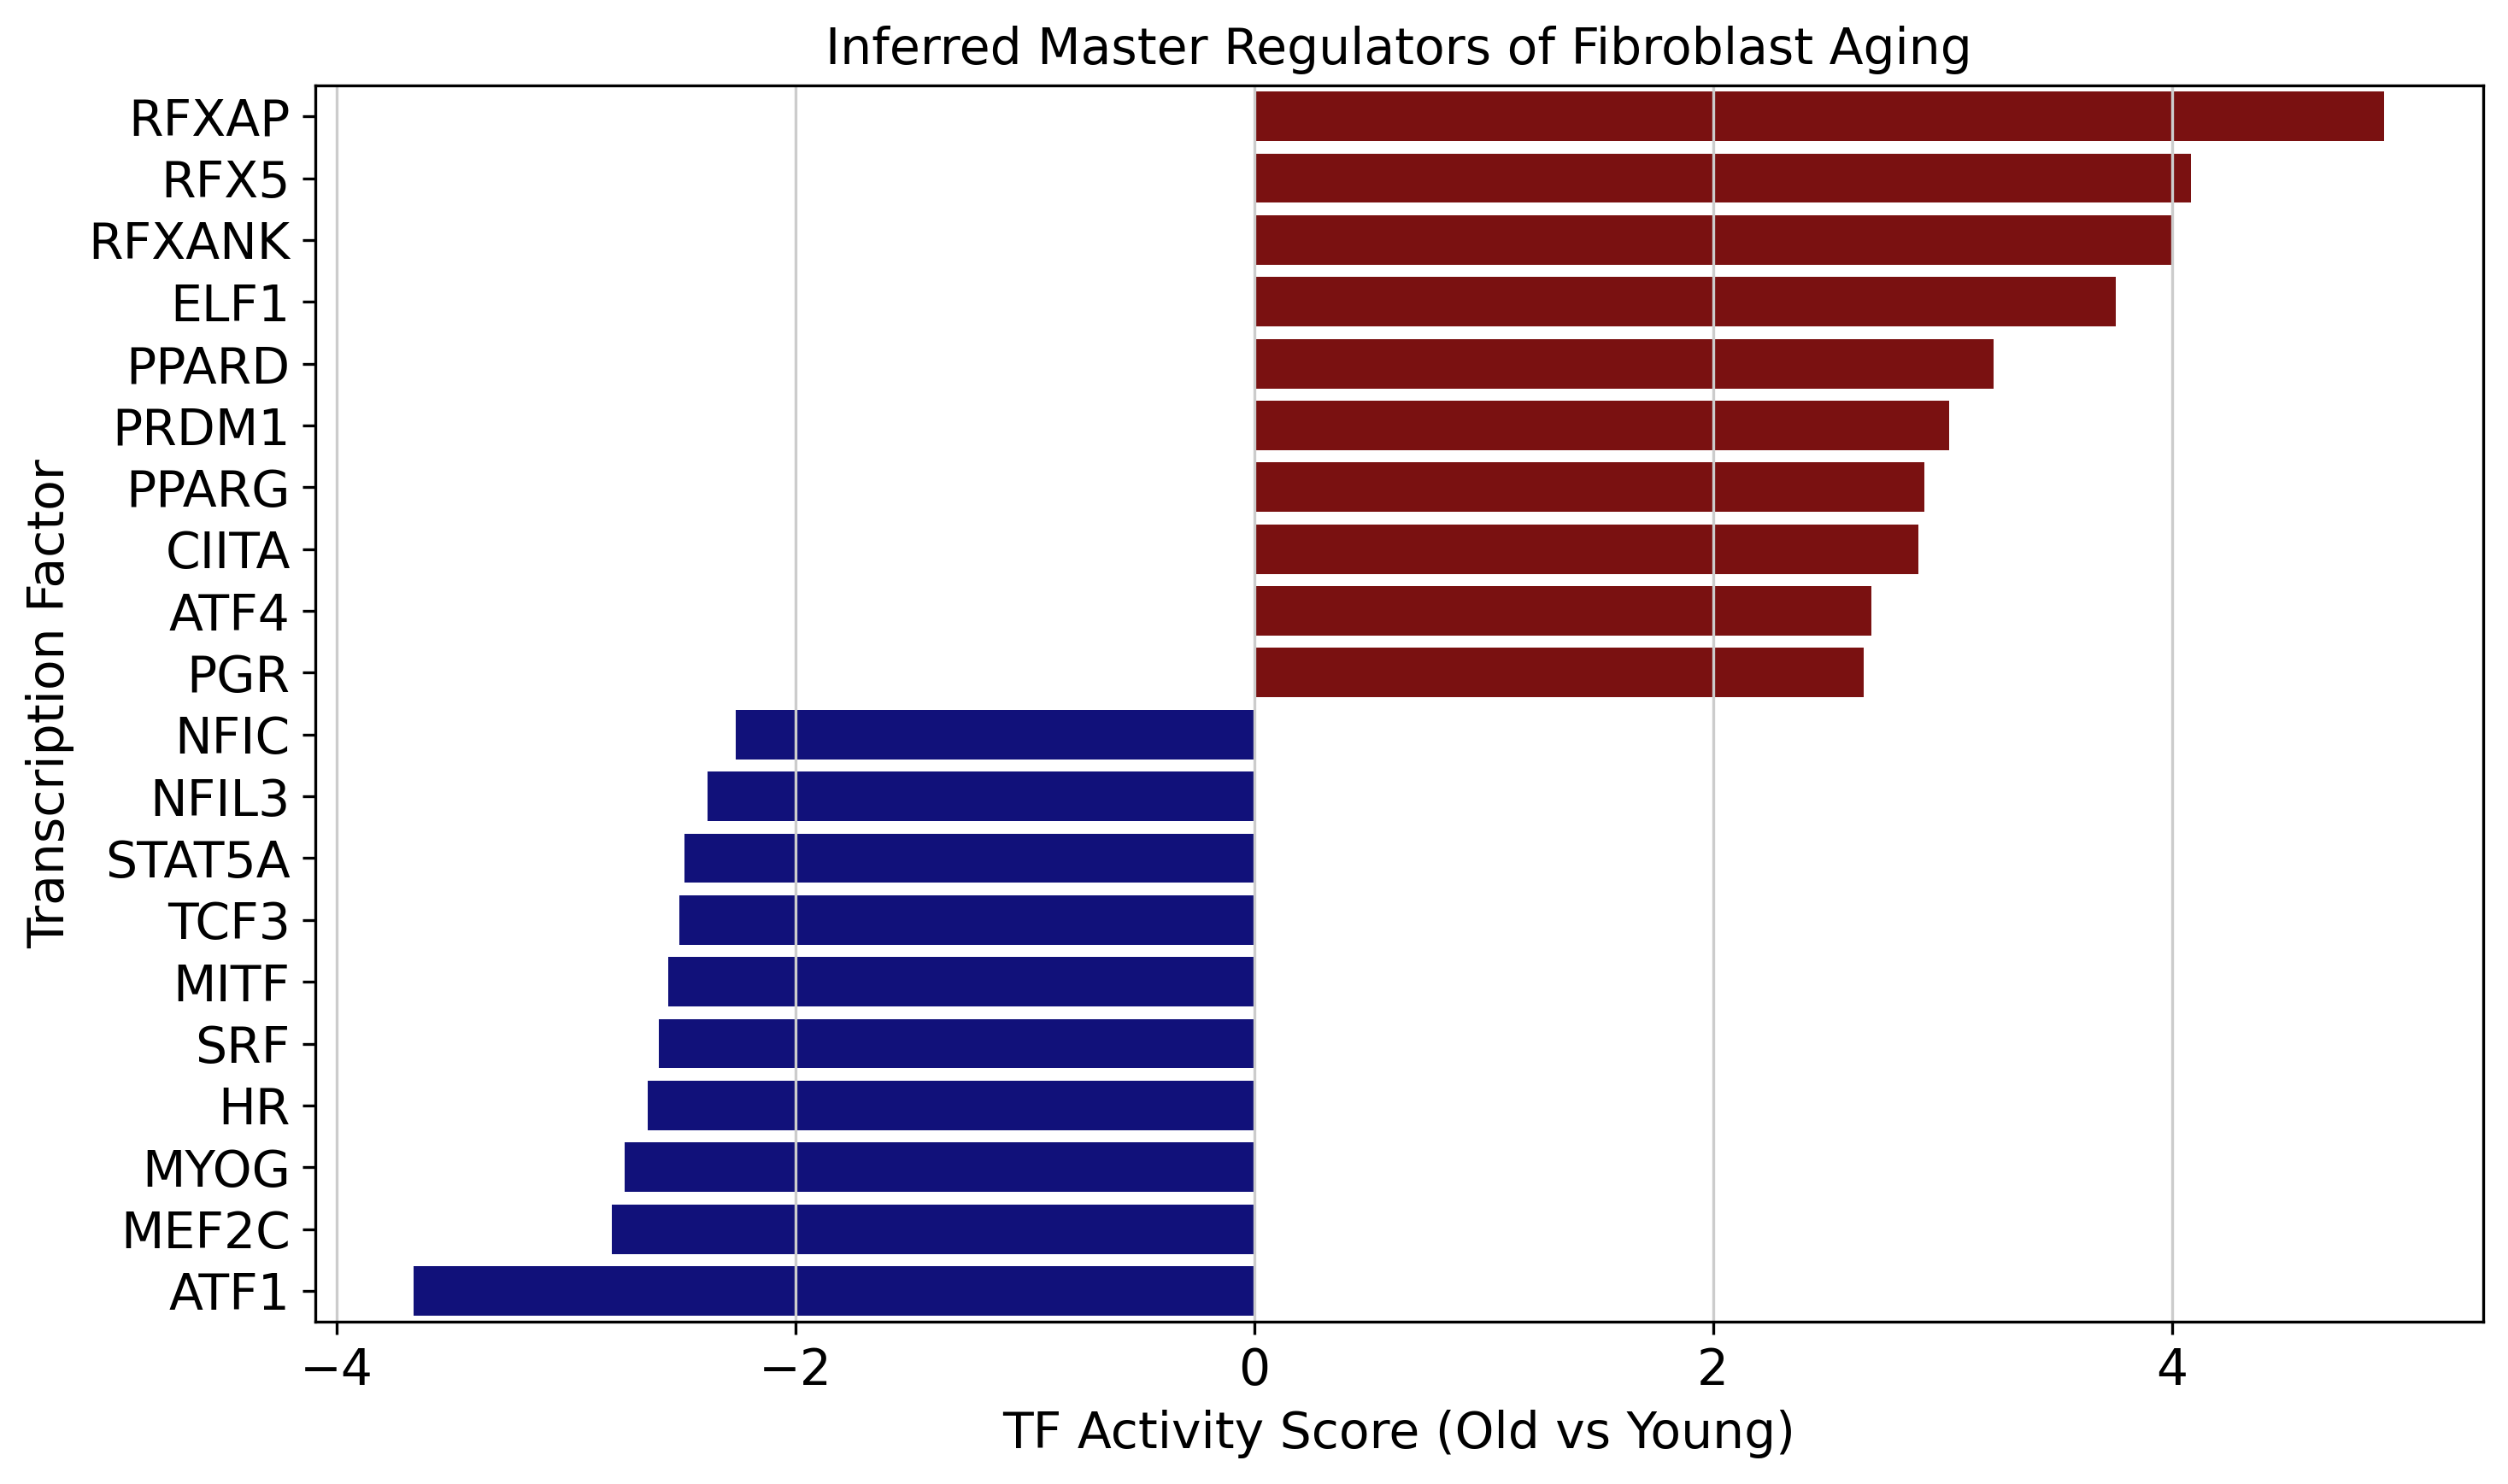

In [ ]:
# [Cell 10: Section I - Upstream TF Inference (Robust API Bypass)]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_1samp
import os

print("1. Bypassing package API and fetching CollecTRI directly from Omnipath servers...")
# FIX: Added '&genesymbols=1' to force the server to return human-readable gene names
url = "https://omnipathdb.org/interactions?datasets=collectri&format=tsv&genesymbols=1"
omnipath_df = pd.read_csv(url, sep='\t')

print("2. Parsing regulatory network...")
# Defensive check: Automatically adapt to the column names the server provides
if 'source_genesymbol' in omnipath_df.columns:
    src_col = 'source_genesymbol'
    tgt_col = 'target_genesymbol'
else:
    src_col = 'source'
    tgt_col = 'target'

# Convert Omnipath TSV into biological logic (+1 stimulation / -1 inhibition)
omnipath_df['weight'] = 0
if 'is_stimulation' in omnipath_df.columns:
    omnipath_df.loc[omnipath_df['is_stimulation'] == 1, 'weight'] = 1
    omnipath_df.loc[omnipath_df['is_inhibition'] == 1, 'weight'] = -1

# Keep unambiguous interactions
net = omnipath_df[omnipath_df['weight'] != 0].copy()
net = net[[src_col, tgt_col, 'weight']]
net.columns = ['source', 'target', 'weight']
net = net.drop_duplicates(subset=['source', 'target'])

print(f"Successfully loaded {len(net)} CollecTRI interactions.")

print("3. Executing Native Parametric Enrichment Analysis (TF Inference)...")
res_clean = res_df.dropna(subset=['stat']).copy()
gene_stats = res_clean['stat']
tf_scores = []

# Native mathematical inference for Master Regulators
for tf, group in net.groupby('source'):
    # Find targets of this TF that actually exist in our single-cell dataset
    valid_targets = group[group['target'].isin(gene_stats.index)]

    # Require at least 10 measured targets to ensure strict statistical power
    if len(valid_targets) >= 10:
        targets = valid_targets['target']
        weights = valid_targets['weight']

        # Multiply the gene's DESeq2 Wald Stat by the interaction weight.
        signed_stats = gene_stats[targets].values * weights.values

        # 1-sample T-test to prove the target genes are systematically shifting
        t_stat, p_val = ttest_1samp(signed_stats, popmean=0)

        tf_scores.append({
            'TF': tf,
            'Activity_Score': t_stat,
            'p_value': p_val if pd.notna(p_val) else 1.0
        })

tf_res = pd.DataFrame(tf_scores)

print("4. Processing Inference Results...")
# Filter for statistically significant TFs (p < 0.05)
sig_tfs = tf_res[tf_res['p_value'] < 0.05].sort_values('Activity_Score', ascending=False)
sig_tfs.to_csv("Fibroblasts_Old_vs_Young_TF_Activity.csv", index=False)

print(f"\n--- TRANSCRIPTION FACTOR REPORT ---")
print(f"Identified {len(sig_tfs)} significantly deregulated Transcription Factors.")

print("\nTop 10 ACTIVATED TFs in Old Fibroblasts (Drivers of Inflammaging?):")
display(sig_tfs.head(10))

print("\nTop 10 REPRESSED TFs in Old Fibroblasts (Loss of Structural Regulators?):")
display(sig_tfs.tail(10))

# 5. Visualization
os.makedirs('figures', exist_ok=True)
plt.figure(figsize=(10, 6))

# Ensure we have enough TFs to plot
n_top = min(10, len(sig_tfs[sig_tfs['Activity_Score'] > 0]))
n_bot = min(10, len(sig_tfs[sig_tfs['Activity_Score'] < 0]))
top_tfs = pd.concat([sig_tfs.head(n_top), sig_tfs.tail(n_bot)])

sns.barplot(data=top_tfs, x='Activity_Score', y='TF',
            palette=['darkred' if x > 0 else 'darkblue' for x in top_tfs['Activity_Score']])
plt.title("Inferred Master Regulators of Fibroblast Aging")
plt.xlabel("TF Activity Score (Old vs Young)")
plt.ylabel("Transcription Factor")
plt.tight_layout()
plt.savefig("figures/TF_Activity_Barplot.pdf")
plt.show()

In [ ]:
# [Cell 11: Section J - Cell-Cell Communication (LIANA)]
import liana as li
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("1. Isolating Fibroblast and Macrophage populations...")
crosstalk_adata = adata[adata.obs['cell_type'].isin(['Fibroblasts', 'Macrophages'])].copy()

# Ensure data is strictly strictly positive for LIANA's non-negative matrix requirements
if crosstalk_adata.X.min() < 0:
    crosstalk_adata.X[crosstalk_adata.X < 0] = 0

print("2. Running LIANA for YOUNG donors...")
adata_young = crosstalk_adata[crosstalk_adata.obs['age'] == 'YOUNG'].copy()
# rank_aggregate runs multiple consensus scoring methods (CellPhoneDB, NATMI, etc.)
li.mt.rank_aggregate(adata_young, groupby='cell_type', return_all_lrs=True, verbose=False)
y_res = adata_young.uns['liana_res']

print("3. Running LIANA for OLD donors...")
adata_old = crosstalk_adata[crosstalk_adata.obs['age'] == 'OLD'].copy()
li.mt.rank_aggregate(adata_old, groupby='cell_type', return_all_lrs=True, verbose=False)
o_res = adata_old.uns['liana_res']

print("4. Filtering for Fibroblast (Sender) -> Macrophage (Receiver) Communication...")
y_f2m = y_res[(y_res['source'] == 'Fibroblasts') & (y_res['target'] == 'Macrophages')].copy()
o_f2m = o_res[(o_res['source'] == 'Fibroblasts') & (o_res['target'] == 'Macrophages')].copy()

# A low specificity_rank means the interaction is highly specific to these two cells
# We filter for statistically significant communication pathways
y_sig = y_f2m[y_f2m['cellphone_pvals'] < 0.05].copy()
o_sig = o_f2m[o_f2m['cellphone_pvals'] < 0.05].copy()

# Format the pairs for easy reading (Ligand -> Receptor)
y_sig['interaction'] = y_sig['ligand_complex'] + " -> " + y_sig['receptor_complex']
o_sig['interaction'] = o_sig['ligand_complex'] + " -> " + o_sig['receptor_complex']

print(f"\nBaseline: Found {len(y_sig)} significant signaling axes in Young skin.")
print(f"Aged: Found {len(o_sig)} significant signaling axes in Old skin.")

print("5. Calculating Network Rewiring...")
# Interactions that ONLY exist in Old skin (Emergent SASP signals)
emergent = set(o_sig['interaction']) - set(y_sig['interaction'])
# Interactions that ONLY exist in Young skin (Lost homeostatic signals)
lost = set(y_sig['interaction']) - set(o_sig['interaction'])

print("\n--- EMERGENT SIGNALING AXES (Activated during Aging) ---")
if len(emergent) > 0:
    for i in list(emergent)[:15]:
        print(f"🚨 {i}")
else:
    print("No entirely novel emergent interactions found. Aging may alter magnitude rather than presence.")

print("\n--- LOST SIGNALING AXES (Silenced during Aging) ---")
if len(lost) > 0:
    for i in list(lost)[:15]:
        print(f"📉 {i}")
else:
    print("No entirely lost interactions found.")

# Save to CSV for the manuscript
o_sig.to_csv("Aged_Fibroblast_to_Macrophage_Crosstalk.csv", index=False)

1. Isolating Fibroblast and Macrophage populations...
2. Running LIANA for YOUNG donors...
3. Running LIANA for OLD donors...
4. Filtering for Fibroblast (Sender) -> Macrophage (Receiver) Communication...

Baseline: Found 162 significant signaling axes in Young skin.
Aged: Found 121 significant signaling axes in Old skin.
5. Calculating Network Rewiring...

--- EMERGENT SIGNALING AXES (Activated during Aging) ---
🚨 HRAS -> CAV1
🚨 MYL9 -> CD69
🚨 PLA2G2A -> ITGAV
🚨 LGALS1 -> CD69
🚨 PLA2G2A -> ITGA5
🚨 CTHRC1 -> FZD6
🚨 MXRA5 -> CD69
🚨 CCL21 -> CCR7
🚨 GNAI2 -> S1PR1
🚨 PLA2G2A -> ITGB1
🚨 GNAS -> ADRB2

--- LOST SIGNALING AXES (Silenced during Aging) ---
📉 LGALS3BP -> CD33
📉 VEGFA -> FLT1_KDR
📉 LAMA2 -> RPSA
📉 PGF -> NRP2
📉 FN1 -> SDC2
📉 FN1 -> C5AR1
📉 VEGFB -> ADRB2
📉 TNFSF13B -> CD40
📉 MIF -> CD44_CD74
📉 COPA -> CD74
📉 MXRA5 -> PILRA
📉 SLPI -> CD4
📉 ICAM1 -> CAV1
📉 LAMA2 -> ITGA6_ITGB1
📉 ANG -> PLXNB2
